In [66]:
import pandas as pd

In [67]:
import seaborn as sns

In [68]:
import matplotlib.pyplot as plt

In [69]:
import numpy as np

In [70]:
import warnings

In [71]:
warnings.filterwarnings("ignore")

In [72]:
df=pd.read_csv(r"C:\Users\Hello\Downloads\enhanced_customer_purchase_dataset.csv")
df

,customer_id,customer_name,purchase_year,purchase_month,purchase_day,purchase_hour,day_of_week,is_weekend,salary,card_form,exchange_level,will_buy_product
0,12965,Kimberly Davis,2023,2,24,0,Friday,0,84458,3,3,0
1,10969,Stephanie King,2023,7,10,6,Monday,0,56071,1,1,0
2,11385,Andrea White,2023,10,27,3,Friday,0,62046,2,3,0
3,11233,Tabitha Flores,2023,2,11,23,Saturday,1,63849,2,2,1
4,12996,Joanna Moran,2023,11,27,7,Monday,0,69402,2,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3145,12414,Katherine Becker,2024,7,28,2,Sunday,1,61802,2,3,1
3146,11095,Stacey Lopez,2023,11,12,4,Sunday,1,45308,1,3,0
3147,11130,Olivia Murray,2023,4,20,16,Thursday,0,52792,1,2,1
3148,11294,Julie Mckay,2024,10,8,18,Tuesday,0,56479,1,1,1


In [73]:
df.head()

,customer_id,customer_name,purchase_year,purchase_month,purchase_day,purchase_hour,day_of_week,is_weekend,salary,card_form,exchange_level,will_buy_product
0,12965,Kimberly Davis,2023,2,24,0,Friday,0,84458,3,3,0
1,10969,Stephanie King,2023,7,10,6,Monday,0,56071,1,1,0
2,11385,Andrea White,2023,10,27,3,Friday,0,62046,2,3,0
3,11233,Tabitha Flores,2023,2,11,23,Saturday,1,63849,2,2,1
4,12996,Joanna Moran,2023,11,27,7,Monday,0,69402,2,3,1


In [74]:
df.shape

(3150, 12)

In [75]:
df.columns

Index(['customer_id', 'customer_name', 'purchase_year', 'purchase_month',
       'purchase_day', 'purchase_hour', 'day_of_week', 'is_weekend', 'salary',
       'card_form', 'exchange_level', 'will_buy_product'],
      dtype='object')

In [76]:
df.dtypes

customer_id          int64
customer_name       object
purchase_year        int64
purchase_month       int64
purchase_day         int64
purchase_hour        int64
day_of_week         object
is_weekend           int64
salary               int64
card_form            int64
exchange_level       int64
will_buy_product     int64
dtype: object

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       3150 non-null   int64 
 1   customer_name     3150 non-null   object
 2   purchase_year     3150 non-null   int64 
 3   purchase_month    3150 non-null   int64 
 4   purchase_day      3150 non-null   int64 
 5   purchase_hour     3150 non-null   int64 
 6   day_of_week       3150 non-null   object
 7   is_weekend        3150 non-null   int64 
 8   salary            3150 non-null   int64 
 9   card_form         3150 non-null   int64 
 10  exchange_level    3150 non-null   int64 
 11  will_buy_product  3150 non-null   int64 
dtypes: int64(10), object(2)
memory usage: 295.4+ KB


### NANS

In [78]:
df.isna().sum()

customer_id         0
customer_name       0
purchase_year       0
purchase_month      0
purchase_day        0
purchase_hour       0
day_of_week         0
is_weekend          0
salary              0
card_form           0
exchange_level      0
will_buy_product    0
dtype: int64

In [79]:
df.isna().sum().sum()

0

In [80]:
df=df.drop(["customer_id","customer_name"],axis=1)
df

,purchase_year,purchase_month,purchase_day,purchase_hour,day_of_week,is_weekend,salary,card_form,exchange_level,will_buy_product
0,2023,2,24,0,Friday,0,84458,3,3,0
1,2023,7,10,6,Monday,0,56071,1,1,0
2,2023,10,27,3,Friday,0,62046,2,3,0
3,2023,2,11,23,Saturday,1,63849,2,2,1
4,2023,11,27,7,Monday,0,69402,2,3,1
...,...,...,...,...,...,...,...,...,...,...
3145,2024,7,28,2,Sunday,1,61802,2,3,1
3146,2023,11,12,4,Sunday,1,45308,1,3,0
3147,2023,4,20,16,Thursday,0,52792,1,2,1
3148,2024,10,8,18,Tuesday,0,56479,1,1,1


<function matplotlib.pyplot.show(close=None, block=None)>

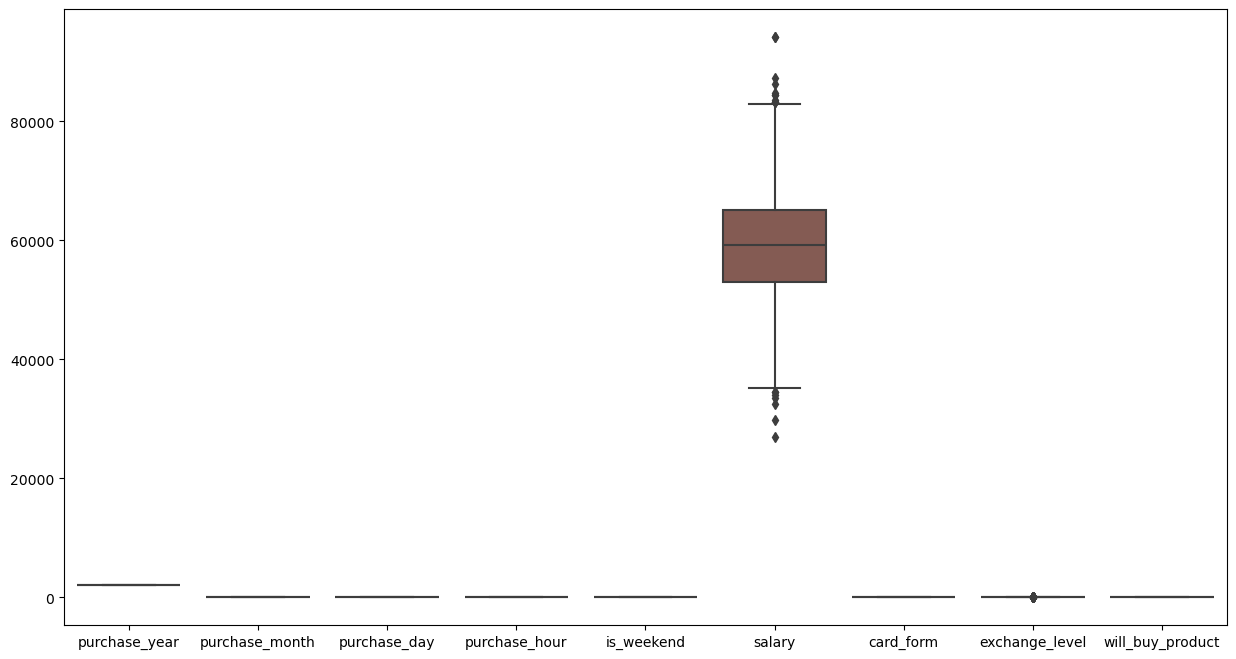

In [81]:
plt.figure(figsize=(15,8))
sns.boxplot(df)
plt.show

### IQR METHOD

In [82]:
    q1 = df["salary"].quantile(0.25)
    q3 = df["salary"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)
    df["salary"] = df["salary"].map(lambda x : lower if x < lower else upper if x > upper else x)

<function matplotlib.pyplot.show(close=None, block=None)>

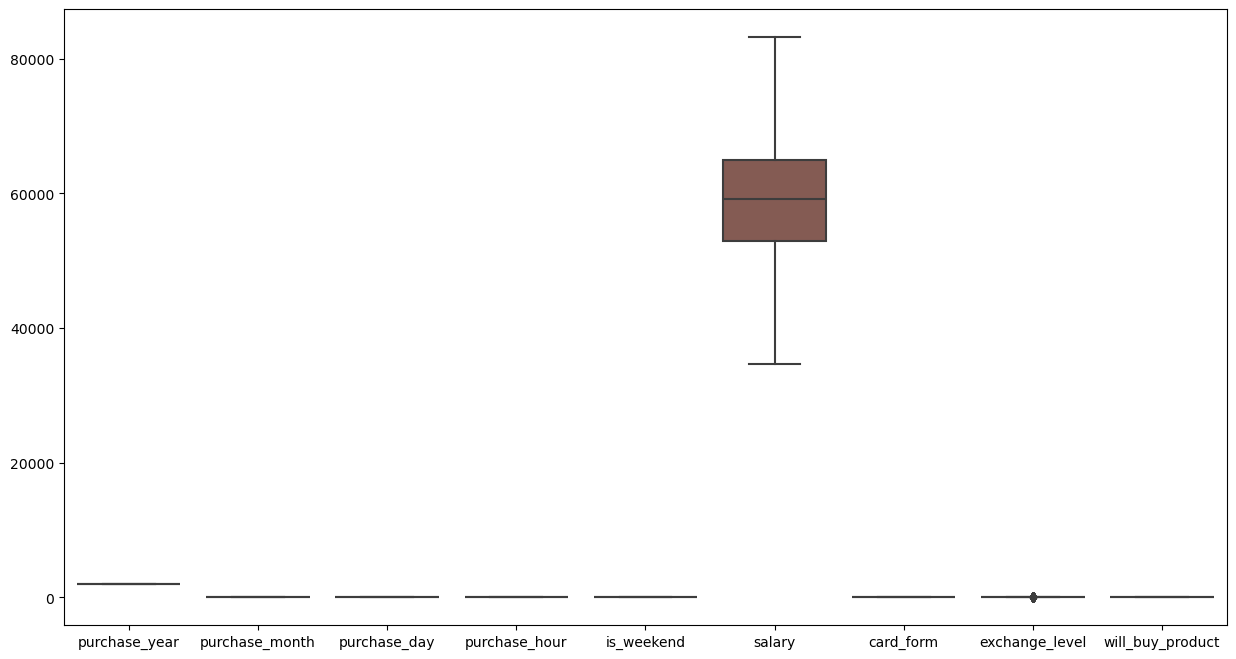

In [83]:
plt.figure(figsize=(15,8))
sns.boxplot(df)
plt.show

### ENCODING

In [84]:
df.head()

,purchase_year,purchase_month,purchase_day,purchase_hour,day_of_week,is_weekend,salary,card_form,exchange_level,will_buy_product
0,2023,2,24,0,Friday,0,83241.25,3,3,0
1,2023,7,10,6,Monday,0,56071.00,1,1,0
2,2023,10,27,3,Friday,0,62046.00,2,3,0
3,2023,2,11,23,Saturday,1,63849.00,2,2,1
4,2023,11,27,7,Monday,0,69402.00,2,3,1


In [85]:
df=pd.get_dummies(df,dtype="int")
df

,purchase_year,purchase_month,purchase_day,purchase_hour,is_weekend,salary,card_form,exchange_level,will_buy_product,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,2023,2,24,0,0,83241.25,3,3,0,1,0,0,0,0,0,0
1,2023,7,10,6,0,56071.00,1,1,0,0,1,0,0,0,0,0
2,2023,10,27,3,0,62046.00,2,3,0,1,0,0,0,0,0,0
3,2023,2,11,23,1,63849.00,2,2,1,0,0,1,0,0,0,0
4,2023,11,27,7,0,69402.00,2,3,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,2024,7,28,2,1,61802.00,2,3,1,0,0,0,1,0,0,0
3146,2023,11,12,4,1,45308.00,1,3,0,0,0,0,1,0,0,0
3147,2023,4,20,16,0,52792.00,1,2,1,0,0,0,0,1,0,0
3148,2024,10,8,18,0,56479.00,1,1,1,0,0,0,0,0,1,0


### DATA SEPERATION

In [86]:
X=df.drop(["will_buy_product"],axis=1)
X

,purchase_year,purchase_month,purchase_day,purchase_hour,is_weekend,salary,card_form,exchange_level,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,2023,2,24,0,0,83241.25,3,3,1,0,0,0,0,0,0
1,2023,7,10,6,0,56071.00,1,1,0,1,0,0,0,0,0
2,2023,10,27,3,0,62046.00,2,3,1,0,0,0,0,0,0
3,2023,2,11,23,1,63849.00,2,2,0,0,1,0,0,0,0
4,2023,11,27,7,0,69402.00,2,3,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,2024,7,28,2,1,61802.00,2,3,0,0,0,1,0,0,0
3146,2023,11,12,4,1,45308.00,1,3,0,0,0,1,0,0,0
3147,2023,4,20,16,0,52792.00,1,2,0,0,0,0,1,0,0
3148,2024,10,8,18,0,56479.00,1,1,0,0,0,0,0,1,0


In [87]:
y=df["will_buy_product"]
y

0       0
1       0
2       0
3       1
4       1
       ..
3145    1
3146    0
3147    1
3148    1
3149    1
Name: will_buy_product, Length: 3150, dtype: int64

### IMBLANCE

In [88]:
y.value_counts()

will_buy_product
1    2242
0     908
Name: count, dtype: int64

In [89]:
from imblearn.over_sampling import RandomOverSampler

In [90]:
ros=RandomOverSampler()

In [91]:
ros

RandomOverSampler()

In [92]:
X_ros,y_ros=ros.fit_resample(X,y)

In [93]:
X.shape

(3150, 15)

In [94]:
X_ros.shape

(4484, 15)

In [95]:
y.value_counts()

will_buy_product
1    2242
0     908
Name: count, dtype: int64

In [96]:
y_ros.value_counts()

will_buy_product
0    2242
1    2242
Name: count, dtype: int64

<Axes: xlabel='will_buy_product'>

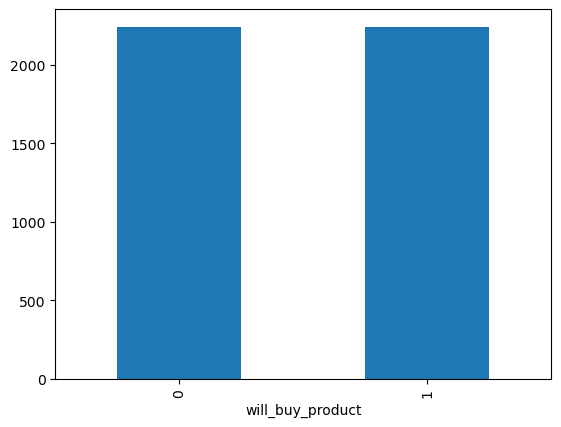

In [97]:
y_ros.value_counts().plot(kind="bar")

### DATA SPLITTING

In [98]:
from sklearn.model_selection import train_test_split

In [108]:
X_train,X_test,y_train,y_test=train_test_split(X_ros,y_ros,test_size=0.20,random_state=42)

In [109]:
X_train.shape

(3587, 15)

In [110]:
X_test.shape

(897, 15)

In [111]:
X_ros.shape

(4484, 15)

### FEATURE SCALING

#### STANDRADIZATION

In [113]:
from sklearn.preprocessing import StandardScaler

In [114]:
ss=StandardScaler()

In [115]:
ss

StandardScaler()

In [117]:

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [118]:
X_train

array([[-0.99749408,  0.99726788, -0.91955259, ..., -0.43647199,
        -0.40525596, -0.41083405],
       [ 1.00251222, -1.00452277,  0.33965427, ..., -0.43647199,
         2.4675763 , -0.41083405],
       [ 1.00251222,  1.56920807,  0.22518092, ..., -0.43647199,
        -0.40525596,  2.43407281],
       ...,
       [ 1.00251222,  0.99726788,  1.36991443, ..., -0.43647199,
        -0.40525596, -0.41083405],
       [-0.99749408, -1.00452277,  0.11070757, ..., -0.43647199,
        -0.40525596, -0.41083405],
       [-0.99749408, -0.71855268, -1.72086604, ..., -0.43647199,
        -0.40525596, -0.41083405]])

In [119]:
X_test

array([[ 1.00251222, -0.14661249,  0.68307432, ..., -0.43647199,
        -0.40525596, -0.41083405],
       [ 1.00251222,  0.99726788, -0.91955259, ..., -0.43647199,
         2.4675763 , -0.41083405],
       [-0.99749408, -1.57646296,  0.11070757, ..., -0.43647199,
         2.4675763 , -0.41083405],
       ...,
       [ 1.00251222,  1.28323798, -0.00376578, ..., -0.43647199,
        -0.40525596, -0.41083405],
       [-0.99749408, -1.57646296, -1.26297264, ...,  2.29109775,
        -0.40525596, -0.41083405],
       [-0.99749408, -1.29049286, -1.26297264, ..., -0.43647199,
        -0.40525596, -0.41083405]])

In [120]:
X_train.mean()

5.731288813422631e-15

In [121]:
X_test.mean()

0.0012429725880602148

In [123]:
X_train.std()

1.0

In [124]:
X_test.std()

0.998592890716338

In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [132]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc}")

Logistic Regression Accuracy: 0.6376811594202898
KNN Accuracy: 0.6778149386845039
Decision Tree Accuracy: 0.8316610925306578
Random Forest Accuracy: 0.8539576365663322


In [133]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[414  24]
 [104 355]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       438
           1       0.94      0.77      0.85       459

    accuracy                           0.86       897
   macro avg       0.87      0.86      0.86       897
weighted avg       0.87      0.86      0.86       897



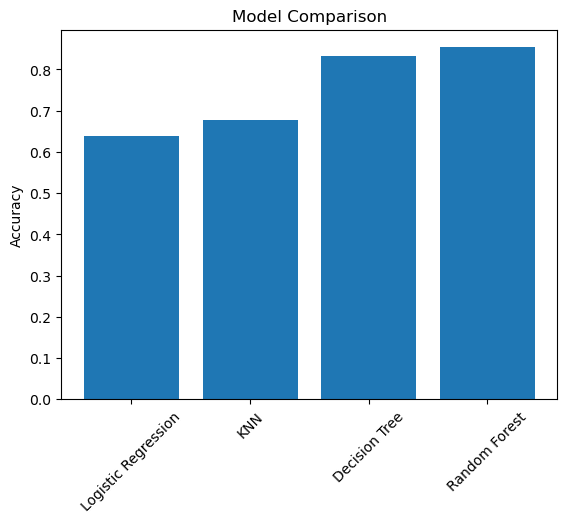

In [134]:
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

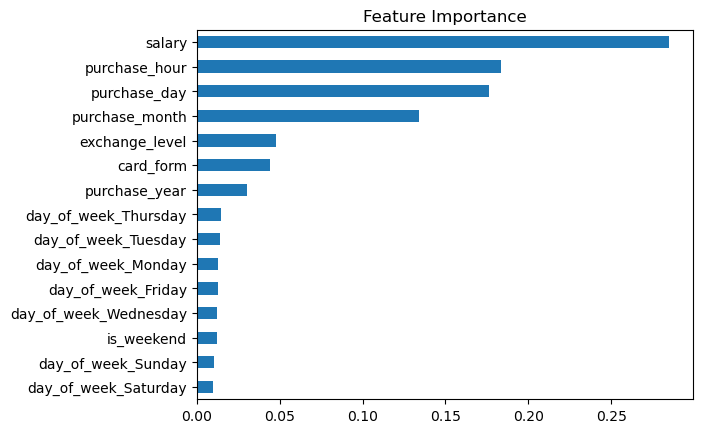

In [135]:
importances = best_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()